## Capstone assignment (SLMSHA047)

This notebook belongs to Shaakirah Sulaiman and will produce the required figures of the Capstone assignment.

In [1]:
#importing all the necessary packages 
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import seaborn as sns

## Map of the bathymetry

In [2]:
# Saves file directory into a variable 
file_bath = "C:/Users/Shaakirah/OneDrive/Documents/SAMOS/Modules/Core3/Python_applications/Capstone_assignment/Chile_bathymetry_20260513_CF.grd"

# creates an array of the variables and saves it as ds
ds_bath = xr.open_dataset(file_bath)

Text(-0.13, 0.5, 'Latitude (°)')

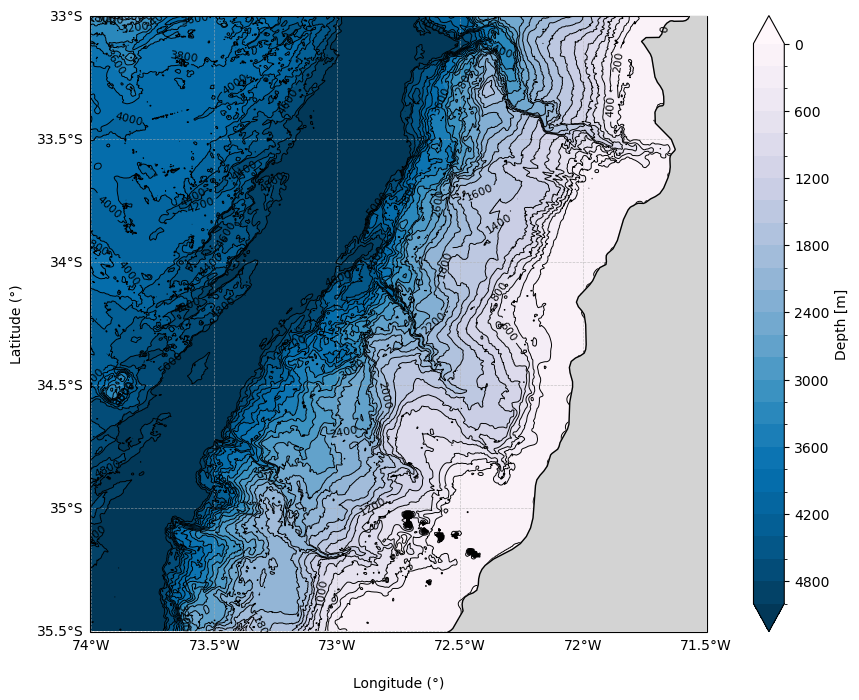

In [3]:
fig = plt.figure(figsize=(12, 8))              # Sets the size of the figure

depth = -ds_bath.altitude                      # Convert altitude to positive depth

ax = plt.axes(projection=ccrs.PlateCarree())   # Sets map projection

# Plot positive depth values
bathy = depth.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=np.arange(0, 5001, 200),
    cmap='PuBu',
    zorder=1,
    cbar_kwargs={'label': 'Depth [m]'}          # Change colorbar label)
)

bathy.colorbar.ax.invert_yaxis()

# Land and coastlines
ax.add_feature(cfeature.LAND, 
               color='lightgrey', 
               zorder=3)                        # Adds coastal land as the third layer
ax.coastlines(resolution='10m', zorder=4)       # Adds coastaline as the top layer

# Adds gridlines 
gl = ax.gridlines(draw_labels=True,                          
                  linestyle='--',
                  linewidth=0.5,
                  alpha=0.7)

gl.top_labels = False                      # Removes top grid labels
gl.right_labels = False                    # Removes right grid labels
gl.xlabel_style = {'rotation': 0}          # Set x labels on a straight line

# Bathymetry contour lines
contours = depth.plot.contour(
    ax=ax,
    levels=np.arange(0, 5001, 200),
    colors='black',
    linewidths=0.7,
    transform=ccrs.PlateCarree()
)

ax.clabel(contours, fontsize=8)            # Label contour lines

            
ax.text(0.5, -0.09, 'Longitude (°)',       # Label the X axis as Longitude
        transform=ax.transAxes,
        ha='center')

ax.text(-0.13, 0.5, 'Latitude (°)',        # Label the Y axis as Latitude
        transform=ax.transAxes,
        rotation='vertical',
        va='center')                  


## Map of the mean annual chlorophyll

In [4]:
import matplotlib.colors as colors

In [5]:
file_chl = "C:/Users/Shaakirah/OneDrive/Documents/SAMOS/Modules/Core3/Python_applications/Capstone_assignment/ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc"

ds_chl = xr.open_dataset(file_chl)         # opens dataset into an xarray

chl = ds_chl['chlor_a']                    # Adds the chlorphyll data to a recallable variable 

chl_chile = ds_chl.sel(                    # boxes the data to my chosen region (Valparaíso, Chile)
    lat=slice(-33.0, -35.5),  
    lon=slice(-74.0, -71.5)
)

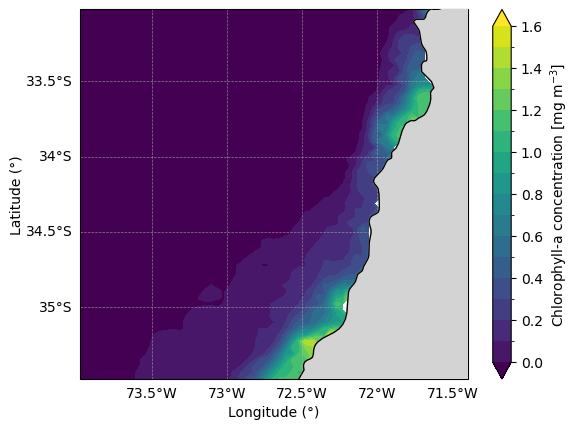

In [6]:
ax = plt.axes(projection=ccrs.PlateCarree())   # Sets map projection

log_chl = np.log(chl_chile['chlor_a'])         # creates a log variable of the logged chloropyhll data for Valparaíso
chl_mean = log_chl.mean(dim='time')            # creates a mean variable of the logged chlorophyll data across 12 months for the region
chl_mean.plot.contourf(levels=np.arange(0.,1.7,0.1),
                       cmap='viridis',
                       cbar_kwargs={'label': 'Chlorophyll-a concentration [mg m$^{-3}$]'}   
                      )                        # Plots the mean logged chlorophyll data onto a contour filled plot

# Land and coastlines
ax.add_feature(cfeature.LAND, 
               color='lightgrey', 
               zorder=3)                        # Adds coastal land as the third layer
ax.coastlines(resolution='10m', zorder=4)       # Adds coastaline as the top layer

gl = ax.gridlines(draw_labels=True,        # Adds gridlines                        
                  linestyle='--',
                  linewidth=0.5,
                  alpha=0.7,
                 zorder=5)

gl.top_labels = False                      # Removes top grid labels
gl.right_labels = False                    # Removes right grid labels
gl.xlabel_style = {'rotation': 0}          # Set x labels on a straight line

ax.text(0.5, -0.10, 'Longitude (°)',       # Adds a x-label 
        transform=ax.transAxes,
        ha='center')

ax.text(-0.18, 0.5, 'Latitude (°)',        # Adds a y-label
        transform=ax.transAxes,
        rotation='vertical',
        va='center')

plt.show()

## Faceted map of the seasons 

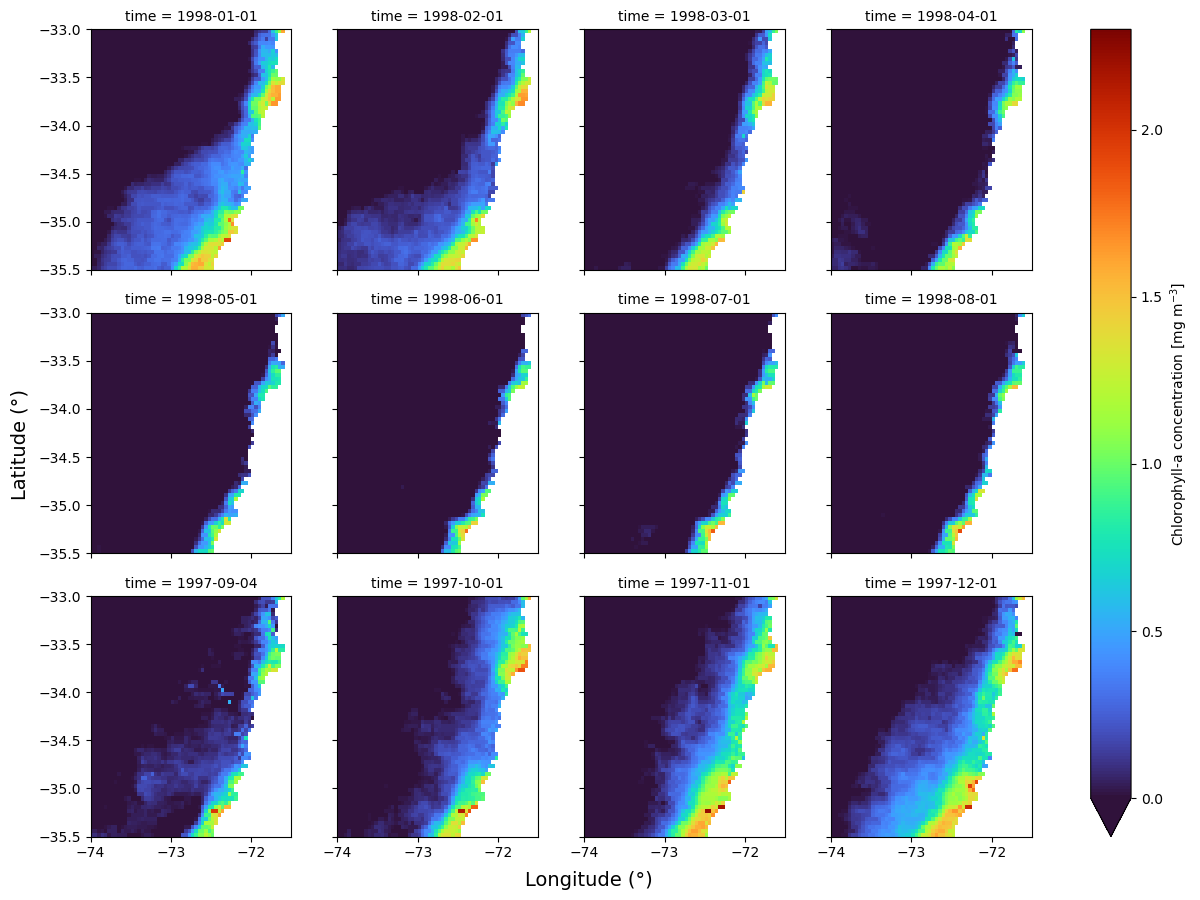

In [7]:
season = log_chl.plot(col = 'time',             #  Plots the logged chloropyhll data according to time factors (months)
             col_wrap = 4,
             cmap = 'turbo', 
             vmin = 0, 
             vmax = 2.3,
             cbar_kwargs={'label': 'Chlorophyll-a concentration [mg m$^{-3}$]'} 
            )

for ax in season.axs.flat:                      # Reomoves the axis labels of the individual plots
    ax.set_xlabel("")
    ax.set_ylabel("")

season.fig.text(0.45, 0.01, "Longitude (°)",    # Add one shared x-axis label
                ha='center', fontsize=14)

season.fig.text(0.005, 0.5, "Latitude (°)",     # Add one shared y-axis label
                va='center', rotation='vertical', fontsize=14)

plt.show()

## Plotting time-series of annual mean seasonal cycle and single point

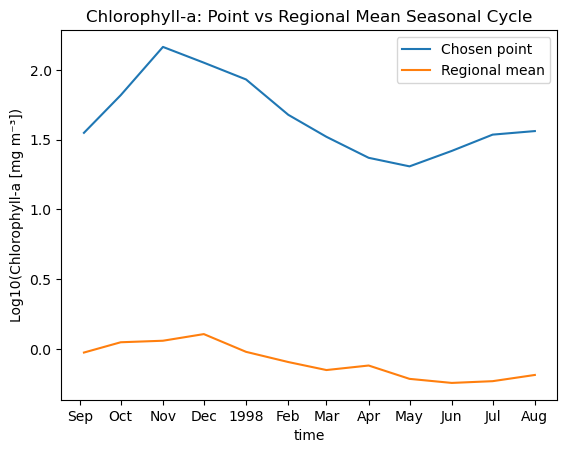

In [9]:
fig, ax = plt.subplots()

chl = log_chl.sortby("time")                               # Sort the logged chloropyhll data in chronological order

point = chl.sel(lat=-35.2, lon=-72.3, method="nearest")    # Selects a se point of the logged chloropyhll data 
region_mean = chl.mean(dim=["lat", "lon"])                 # Calcutlates the mean of the chlorophyll data across longitude and latitude

point.plot(ax=ax, label="Chosen point")                    # Plots the chlorophyll data of that co-ordinate
region_mean.plot(ax=ax, label="Regional mean")             # Plots the mean chlorophyll data region data of that co-ordinate

ax.set_title("Chlorophyll-a: Point vs Regional Mean Seasonal Cycle")
ax.set_ylabel("Log10(Chlorophyll-a [mg m⁻³])")             # Set y_label
ax.legend()                                                # Adds legend of the labels added earleir on 